# 13. CatBoost от начала до конца: цены квартир, 20 000 объектов

| | |
|---|---|
| **Уровень** | 3 из 4 — средние данные: полный цикл и типовые случаи (`3_medium`) |
| **Скрипт-источник** | [`13_catboost_complete.py`](../13_catboost_complete.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 2.1 мин |

**Цель.** Полный рабочий цикл CatBoost и его особенности: категории «из коробки», симметричные деревья, автоподбор темпа.

### Чему вы научитесь

- `Pool` с `cat_features`
- `eval_set` и `use_best_model`
- Значения по умолчанию (1000 деревьев, авто-темп)
- Три вида важности: PredictionValuesChange, LossFunctionChange, SHAP
- Сохранение `.cbm`
- Отключение служебных файлов (`allow_writing_files=False`)

### Данные

`_data.make_houses` — те же 20 000 квартир, что в примере 11; цель — `log(цены)`.

### План

1. **Этап 1.** Данные (цель — логарифм цены)
2. **Этап 2.** Параметры по умолчанию: 1000 симметричных деревьев глубины 6, темп подбирается сам
3. **Этап 3.** Темп 0.1, до 3000 деревьев, ранняя остановка и use_best_model
4. **Этап 4.** Три вида важности
5. **Этап 5.** Сохранение в .cbm
6. **Этап 6.** Сравнение с XGBoost на тех же данных (ранняя остановка у обоих)

> Ноутбук собран из `examples/3_medium/13_catboost_complete.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
import tempfile
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example
from _data import make_houses

ex = Example(EXAMPLES / "3_medium/13_catboost_complete.py", title="13. CatBoost от начала до конца: цены квартир",
             goal="пройти полный цикл CatBoost и увидеть его особенности")

import catboost as cb
import numpy as np
import xgboost as xgb

## Этап 1. Данные (цель — логарифм цены)

In [2]:
X, price = make_houses(ex.size(20_000, 4000))
y = np.log(price)
ex.describe(X, y, target="log(цена)", source="examples/_data.py → make_houses")
n = len(y)
perm = np.random.default_rng(0).permutation(n)
tr, va, te = perm[: int(0.6 * n)], perm[int(0.6 * n): int(0.8 * n)], perm[int(0.8 * n):]
cat_cols = ["район", "ремонт"]
# CatBoost принимает категории строками или целыми числами — переводим pandas.Categorical в строки
Xc = X.assign(**{c: X[c].astype(str) for c in cat_cols})
pool = lambda idx, label=True: cb.Pool(Xc.iloc[idx], y[idx] if label else None, cat_features=cat_cols)
rel_err = lambda logp: float(np.mean(np.abs(price[te] - np.exp(logp)) / price[te]))

   Источник: examples/_data.py → make_houses
   Объектов: 20 000   признаков: 10   память: 1.26 МБ
   Типы признаков: int64 × 5, float64 × 3, category × 2
   Пропуски: кухня 4.9%
   Цель «log(цена)»: среднее 2.063, σ 0.473, мин -0.109, макс 3.552
   Первые строки:


,площадь,комнаты,этаж,этажность,год,до_центра_км,район,парковка,ремонт,кухня,[log(цена)]
0,92.0,4,17,17,2001,6.12,район_06,1,евро,13.7,2.579686
1,62.2,2,6,17,1973,5.29,район_01,0,косметический,10.5,2.263012
2,69.2,3,9,12,1987,7.71,район_00,0,косметический,14.5,2.372391


## Этап 2. Параметры по умолчанию: 1000 симметричных деревьев глубины 6, темп подбирается сам

In [3]:
m0 = cb.CatBoostRegressor(verbose=0, random_seed=0, allow_writing_files=False)
with ex.timer("обучение"):
    m0.fit(pool(tr))
params = m0.get_all_params()
print(f"   деревьев {m0.tree_count_}, темп {params['learning_rate']:.4f} (подобран), глубина {params['depth']}, "
      f"рост {params['grow_policy']}, L2 {params['l2_leaf_reg']}")
print(f"   тест: относительная ошибка {rel_err(m0.predict(pool(te, False))):.1%}")

   ⏱ обучение: 67.78 с
   деревьев 1000, темп 0.0606 (подобран), глубина 6, рост SymmetricTree, L2 3
   тест: относительная ошибка 6.7%


## Этап 3. Темп 0.1, до 3000 деревьев, ранняя остановка и use_best_model

In [4]:
m1 = cb.CatBoostRegressor(iterations=3000, learning_rate=0.1, early_stopping_rounds=200, verbose=0, random_seed=0,
                          allow_writing_files=False)
with ex.timer("обучение"):
    m1.fit(pool(tr), eval_set=pool(va), use_best_model=True)
print(f"   лучшая итерация {m1.get_best_iteration()}, деревьев в модели {m1.tree_count_}")
print(f"   тест: относительная ошибка {rel_err(m1.predict(pool(te, False))):.1%}")
ex.note("""С категориальными признаками CatBoost тратит заметное время на каждое дерево (в нашем окружении — десятки
миллисекунд, урок 9.4), поэтому больший темп и меньше деревьев здесь заметно ускоряют обучение.""")
ex.note("use_best_model=True обрезает модель до лучшей итерации — в отличие от XGBoost, лишних деревьев не остаётся.")

   ⏱ обучение: 52.83 с
   лучшая итерация 586, деревьев в модели 587
   тест: относительная ошибка 6.7%


> ▸ **Вывод.** С категориальными признаками CatBoost тратит заметное время на каждое дерево (в нашем окружении — десятки миллисекунд, урок 9.4), поэтому больший темп и меньше деревьев здесь заметно ускоряют обучение.

> ▸ **Вывод.** use\_best\_model=True обрезает модель до лучшей итерации — в отличие от XGBoost, лишних деревьев не остаётся.

## Этап 4. Три вида важности

   признак       изм. прогноза  изм. потерь   средний |SHAP|
   площадь             46.31      0.26665       0.2900
   район               22.20      0.12073       0.1424
   до_центра_км        17.86      0.09411       0.1279
   ремонт               6.29      0.04132       0.0757
   год                  2.83      0.01425       0.0393
   этаж                 1.02      0.00530       0.0242
   парковка             0.45      0.00306       0.0189
   комнаты              2.29      0.00233       0.0180
   этажность            0.48      0.00246       0.0162
   кухня                0.27     -0.00014       0.0026


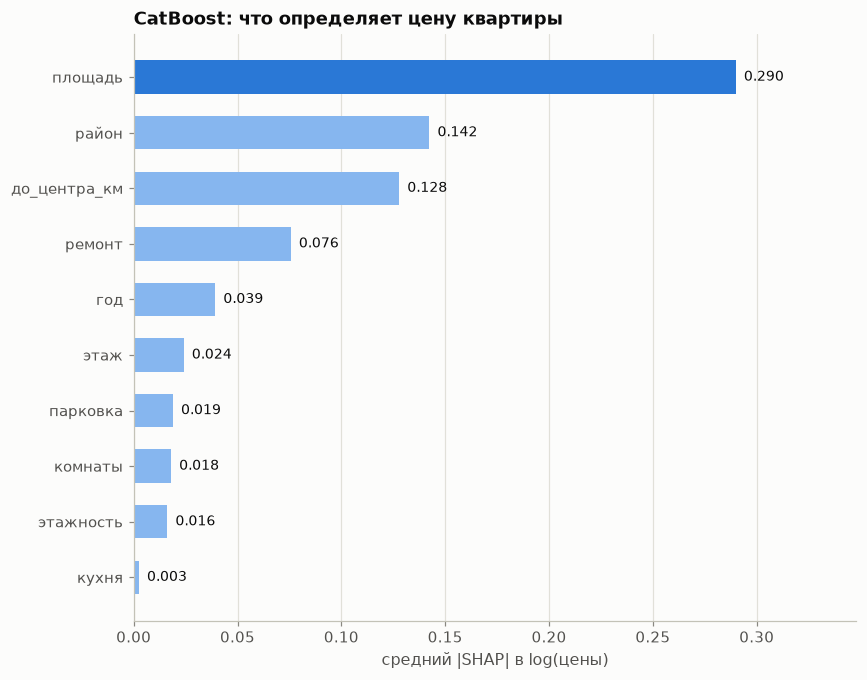

> ▸ **Вывод.** PredictionValuesChange — по обучению, LossFunctionChange — насколько вырастут потери без признака (на валидации).

In [5]:
pvc = m1.get_feature_importance(type="PredictionValuesChange")
lfc = m1.get_feature_importance(pool(va), type="LossFunctionChange")
shap_vals = m1.get_feature_importance(pool(te[:1000]), type="ShapValues")
shap_imp = np.abs(shap_vals[:, :-1]).mean(0)
print("   признак       изм. прогноза  изм. потерь   средний |SHAP|")
for j in np.argsort(-shap_imp):
    print(f"   {X.columns[j]:12s} {pvc[j]:12.2f} {lfc[j]:12.5f} {shap_imp[j]:12.4f}")
assert np.allclose(shap_vals.sum(1), m1.predict(pool(te[:1000], False)), atol=1e-6)
order = np.argsort(-shap_imp)
ex.barh({X.columns[j]: shap_imp[j] for j in order}, best=X.columns[order[0]], name="13_shap_importance",
        xlabel="средний |SHAP| в log(цены)", title="CatBoost: что определяет цену квартиры", fmt="{:.3f}")
ex.note("PredictionValuesChange — по обучению, LossFunctionChange — насколько вырастут потери без признака (на валидации).")

## Этап 5. Сохранение в .cbm

In [6]:
with tempfile.TemporaryDirectory() as d:
    path = Path(d) / "houses.cbm"
    m1.save_model(str(path))
    loaded = cb.CatBoostRegressor().load_model(str(path))
    same = np.allclose(loaded.predict(pool(te, False)), m1.predict(pool(te, False)))
    print(f"   файл {path.stat().st_size / 1024:.0f} КБ; прогнозы совпадают: {same}")
assert same

   файл 880 КБ; прогнозы совпадают: True


## Этап 6. Сравнение с XGBoost на тех же данных (ранняя остановка у обоих)

In [7]:
xm = xgb.XGBRegressor(n_estimators=5000, learning_rate=0.05, max_depth=6, enable_categorical=True, tree_method="hist",
                      early_stopping_rounds=100).fit(X.iloc[tr], y[tr], eval_set=[(X.iloc[va], y[va])], verbose=False)
print(f"   относительная ошибка на тесте: CatBoost {rel_err(m1.predict(pool(te, False))):.2%}, XGBoost {rel_err(xm.predict(X.iloc[te])):.2%}")
ex.done()

   относительная ошибка на тесте: CatBoost 6.71%, XGBoost 7.18%
Готово за 122.4 с


## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Поставьте `grow_policy="Depthwise"` или "Lossguide" и сравните ошибку и время обучения.
2. Передайте район числом, без `cat_features`, — что потеряет модель?
3. Постройте кривые обучения из `m1.get_evals_result()`.

## Что дальше

- **Теория в курсе:** [9.3 «CatBoost»](../../../lessons/lesson_9_3/README.md).
- **Предыдущий пример:** [12. LightGBM от начала до конца: отклик клиентов, 50 000 объектов, редкий класс](12_lightgbm_complete.ipynb)
- **Следующий пример:** [14. HistGradientBoosting из scikit-learn: бустинг без дополнительных библиотек](14_sklearn_hist_gbm.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)